# Job Market Analysis

This notebook analyzes demand, work arrangements, salary information, and skills across the job postings dataset.

In [8]:
from ast import literal_eval
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('..') / 'data'
DATA_FILE = DATA_DIR / 'job_postings_flat.csv'
jobs = pd.read_csv(DATA_FILE, low_memory=False)
jobs['job_posted_date'] = pd.to_datetime(jobs['job_posted_date'], errors='coerce')
jobs['job_skills_list'] = jobs['job_skills'].apply(
    lambda value: literal_eval(value) if isinstance(value, str) and value.startswith('[') else []
)

print(f'Loaded {len(jobs):,} dashboard-aligned job postings')
jobs.head()

Loaded 478,895 dashboard-aligned job postings


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_skills_list
0,Data Analyst,"Summer Internship -Data Analyst Intern, Risk M...","Marlborough, MA",via Boatingrevealed.com,"Full-time, Part-time, and Internship",False,"New York, United States",2024-01-01 00:00:01,False,True,United States,NaN,NaN,NaN,BJ's Wholesale Club,['excel'],{'analyst_tools': ['excel']},[excel]
1,Data Analyst,"Staff Data Analyst Operations, Infrastructure ...","Fremont, CA",via ClimateTechList,Full-time,False,"California, United States",2024-01-01 00:00:11,True,False,United States,NaN,NaN,NaN,Tesla,"['tableau', 'flow']","{'analyst_tools': ['tableau'], 'other': ['flow']}","[tableau, flow]"
2,Data Analyst,Junior Data Analyst - Entry Level,"Waco, TX",via ZipRecruiter,Full-time and Part-time,False,"Texas, United States",2024-01-01 00:00:15,True,False,United States,NaN,NaN,NaN,Next Recruiting,NaN,NaN,[]
3,Data Analyst,"Data Analyst/Engineer, Supply Chain Optimizati...","Austin, TX",via ClimateTechList,Internship,False,"Texas, United States",2024-01-01 00:00:18,False,False,United States,NaN,NaN,NaN,Tesla,['spring'],{'libraries': ['spring']},[spring]
4,Data Scientist,It analyst,"Tampa, FL",via Talent.com,Full-time,False,"Florida, United States",2024-01-01 00:00:29,True,False,United States,NaN,NaN,NaN,VirtualVocations,NaN,NaN,[]


## Demand by Role

In [9]:
role_counts = (
    jobs['job_title_short']
    .value_counts()
    .rename_axis('job_title_short')
    .reset_index(name='job_postings')
)
role_counts

,job_title_short,job_postings
0,Data Engineer,128994
1,Data Analyst,112866
2,Data Scientist,97664
3,Senior Data Engineer,30608
4,Business Analyst,28584
5,Software Engineer,23402
6,Senior Data Scientist,21731
7,Senior Data Analyst,15347
8,Machine Learning Engineer,12860
9,Cloud Engineer,6839


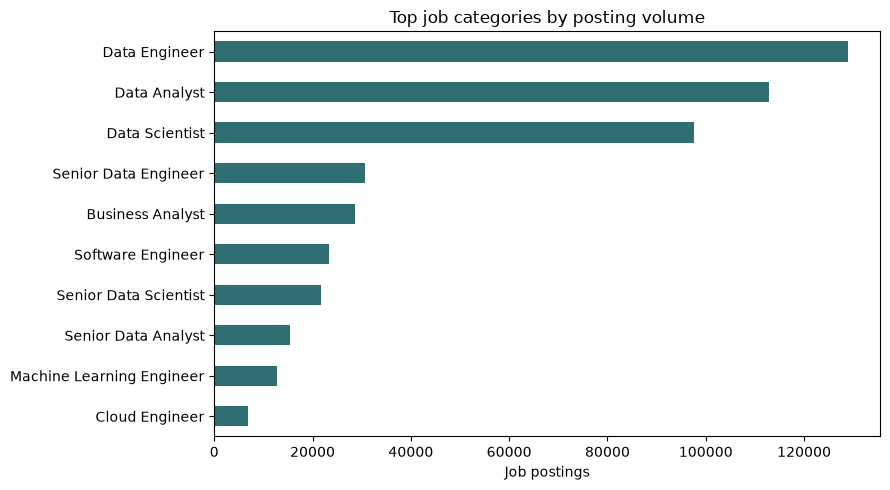

In [10]:
top_roles = role_counts.head(10).sort_values('job_postings')
ax = top_roles.plot.barh(x='job_title_short', y='job_postings', legend=False, figsize=(9, 5), color='#2f6f73')
ax.set_xlabel('Job postings')
ax.set_ylabel('')
ax.set_title('Top job categories by posting volume')
plt.tight_layout()

## Remote Work and Salary

In [11]:
remote_summary = (
    jobs['job_work_from_home']
    .value_counts(dropna=False)
    .rename_axis('job_work_from_home')
    .reset_index(name='job_postings')
)
salary_summary = jobs[['salary_year_avg', 'salary_hour_avg']].describe().T
display(remote_summary)
salary_summary

,job_work_from_home,job_postings
0,False,415900
1,True,62995


,count,mean,std,min,25%,50%,75%,max
salary_year_avg,20335.0,120587.934616,48245.399071,15000.0,85975.0,113250.000000,149589.000000,920000.0
salary_hour_avg,10076.0,49.163118,25.607060,8.0,30.0,47.620003,62.389999,250.0


In [13]:
salary_by_role = (
    jobs.dropna(subset=['salary_year_avg'])
    .groupby('job_title_short', as_index=False)
    .agg(postings_with_salary=('job_title_short', 'count'), median_yearly_salary=('salary_year_avg', 'median'))
    .sort_values('median_yearly_salary', ascending=False)
)
salary_by_role

,job_title_short,postings_with_salary,median_yearly_salary
8,Senior Data Scientist,1259,155500.0
5,Machine Learning Engineer,429,155000.0
7,Senior Data Engineer,1128,146500.0
9,Software Engineer,643,145000.0
3,Data Engineer,3643,126268.0
4,Data Scientist,5065,125000.0
1,Cloud Engineer,61,113837.5
6,Senior Data Analyst,936,107310.0
0,Business Analyst,944,95350.0
2,Data Analyst,6227,90000.0


## Most Requested Skills

The dashboard source stores skills as a list inside each job row. The next cell expands those lists and counts the postings associated with each skill.

In [14]:
skill_counts = (
    jobs[['job_id' if 'job_id' in jobs.columns else 'job_title', 'job_skills_list']]
    .explode('job_skills_list')
    .dropna(subset=['job_skills_list'])
    .rename(columns={'job_skills_list': 'skills'})
    .groupby('skills', as_index=False)
    .agg(job_postings=('job_title', 'count'))
    .sort_values('job_postings', ascending=False)
)
skill_counts.head(20)

,skills,job_postings
165,python,244416
200,sql,240179
14,aws,100386
15,azure,93849
214,tableau,73560
195,spark,71979
169,r,71835
62,excel,71807
158,power bi,66183
97,java,51294


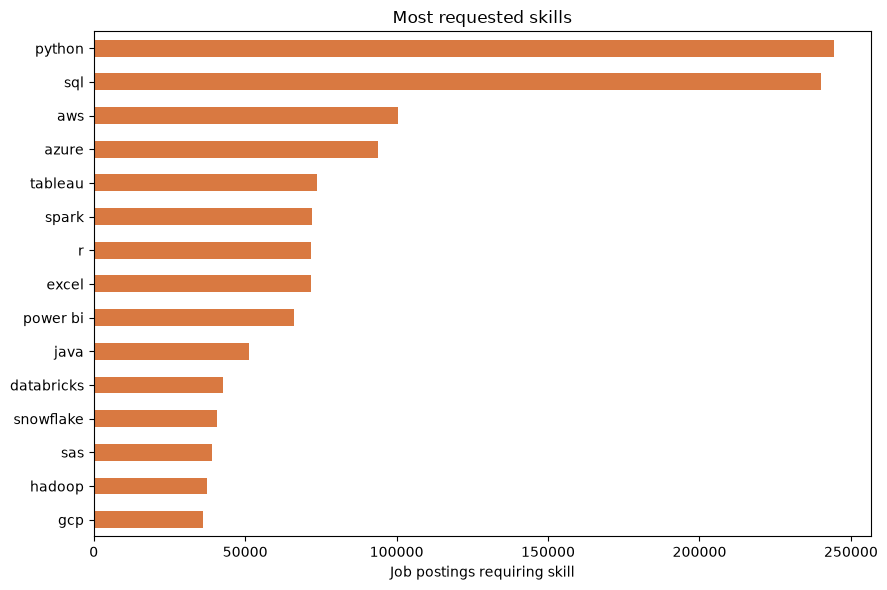

: 

In [ ]:
top_skills = skill_counts.head(15).sort_values('job_postings')
ax = top_skills.plot.barh(x='skills', y='job_postings', legend=False, figsize=(9, 6), color='#d97941')
ax.set_xlabel('Job postings requiring skill')
ax.set_ylabel('')
ax.set_title('Most requested skills')
plt.tight_layout()